# Walk-Forward Parameter Study

Este notebook resume los resultados del análisis Walk-Forward con el objetivo de identificar los hiperparámetros y configuraciones que producen resultados robustos fuera de muestra (Out-of-Sample).

El objetivo no es encontrar una única configuración óptima, sino detectar patrones consistentes asociados a un mejor rendimiento OOS.

In [2]:
import os
import sys

_NOTEBOOK_DIR = os.path.abspath("")
_ROOT = os.path.dirname(_NOTEBOOK_DIR)

_SRC = os.path.join(_ROOT, "src")

if _SRC not in sys.path:
    sys.path.insert(0, _SRC)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.parameter_analysis import (
    parameter_summary,
    compute_feature_importance,
    get_top_configurations,
    get_robust_configurations,
    top_value_frequencies,
)

from analysis.visualization import (
    load_walk_forward_results,
)

In [3]:
df_wf = load_walk_forward_results()

print(f"Configuraciones evaluadas: {len(df_wf)}")
df_wf.head()

Configuraciones evaluadas: 640


,rank_insample,top_n,rebalance_freq,anomaly_lookback_days,momentum_signal,active_cluster,rank_weighted,min_portfolio_size,Sharpe_Train,Sharpe_Test,Degradacion_Sharpe,CAGR_Train (%),CAGR_Test (%),MaxDD_Train (%),MaxDD_Test (%)
0,1,3,Q,1,ALR1W_Z,0,True,5,1.275,0.397,0.878,21.88,5.09,-8.25,-6.51
1,2,3,Q,5,ALR1W_Z,0,True,5,1.275,0.397,0.878,21.88,5.09,-8.25,-6.51
2,3,3,Q,3,ALR1W_Z,0,True,5,1.275,0.397,0.878,21.88,5.09,-8.25,-6.51
3,4,3,Q,3,ALR1W_Z,0,True,4,1.275,0.119,1.156,21.88,1.61,-8.25,-9.61
4,5,3,Q,5,ALR1W_Z,0,True,4,1.275,0.119,1.156,21.88,1.61,-8.25,-9.61


In [4]:
params = [
    "top_n",
    "rebalance_freq",
    "anomaly_lookback_days",
    "momentum_signal",
    "active_cluster",
    "rank_weighted",
    "min_portfolio_size",
]

## 1. Rendimiento medio por hiperparámetro

Se analiza el comportamiento medio de Sharpe_Test para cada valor posible de cada hiperparámetro.

In [5]:
for p in params:

    print("\n")
    print("=" * 80)
    print(p)
    print("=" * 80)

    display(
        parameter_summary(df_wf, p)
    )



top_n


,mean,median,std,max,count
top_n,,,,,
7,0.447644,0.3640,0.561196,2.208,146
6,0.292267,0.2990,0.345975,1.112,120
3,0.280825,0.2080,0.486774,2.153,120
4,0.174607,0.1630,0.816514,2.433,122
5,0.107219,0.1375,0.494369,1.415,128




rebalance_freq


,mean,median,std,max,count
rebalance_freq,,,,,
M,0.696787,0.407,0.710359,2.433,164
Q,0.116271,0.173,0.426612,0.635,472




anomaly_lookback_days


...

,mean,median,std,max,count
active_cluster,,,,,
2,2.317857,2.344,0.113991,2.433,14
3,1.856286,1.783,0.349637,2.208,14
0,0.182097,0.266,0.422986,1.415,608
4,NaN,NaN,NaN,NaN,0




rank_weighted


,mean,median,std,max,count
rank_weighted,,,,,
False,0.316044,0.278,0.626247,2.433,295
True,0.222639,0.299,0.521047,2.365,341




min_portfolio_size


,mean,median,std,max,count
min_portfolio_size,,,,,
3,0.334952,0.242,0.644026,2.433,105
4,0.313673,0.344,0.487806,2.208,220
2,0.297380,0.292,0.719156,2.365,158
5,0.117575,0.233,0.429330,0.668,153


## 2. Importancia relativa de los hiperparámetros

Se entrena un Random Forest utilizando los hiperparámetros como variables explicativas y el Sharpe Out-of-Sample como variable objetivo.

El objetivo no es predecir resultados futuros, sino estimar qué parámetros tienen mayor influencia sobre el desempeño OOS.

In [6]:
importance_df = compute_feature_importance(
    df_wf,
    params,
)

importance_df

,Variable,Importance
4,active_cluster,0.460022
3,momentum_signal,0.280287
1,rebalance_freq,0.092453
0,top_n,0.091886
5,rank_weighted,0.058607
6,min_portfolio_size,0.016474
2,anomaly_lookback_days,0.000270


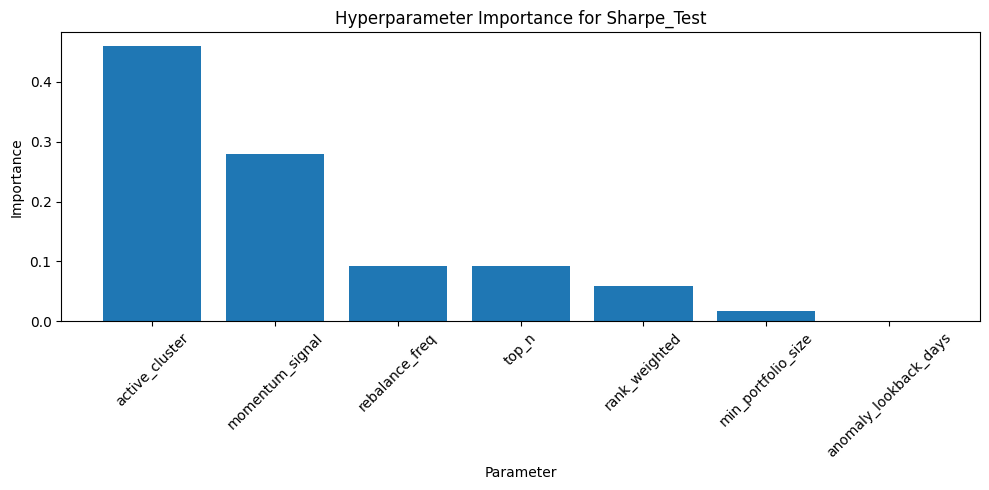

In [7]:
plt.figure(figsize=(10,5))

plt.bar(
    importance_df["Variable"],
    importance_df["Importance"]
)

plt.ylabel("Importance")
plt.xlabel("Parameter")

plt.title(
    "Hyperparameter Importance for Sharpe_Test"
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## 3. Mejores configuraciones OOS

Se muestran las configuraciones con mayor Sharpe fuera de muestra.

In [8]:
top_configs = get_top_configurations(
    df_wf,
    n=20
)

top_configs

,rank_insample,top_n,rebalance_freq,anomaly_lookback_days,momentum_signal,active_cluster,rank_weighted,min_portfolio_size,Sharpe_Train,Sharpe_Test,Degradacion_Sharpe,CAGR_Train (%),CAGR_Test (%),MaxDD_Train (%),MaxDD_Test (%)
545,546,4,M,1,ALR1M_Z,2,False,3,0.835,2.433,-1.598,11.91,49.14,-21.93,-6.46
543,544,4,M,10,ALR1M_Z,2,False,3,0.835,2.433,-1.598,11.91,49.14,-21.93,-6.46
548,549,4,M,3,ALR1M_Z,2,False,3,0.835,2.433,-1.598,11.91,49.14,-21.93,-6.46
541,542,4,M,5,ALR1M_Z,2,False,3,0.835,2.433,-1.598,11.91,49.14,-21.93,-6.46
637,638,4,M,3,ALR1M_Z,2,True,2,0.824,2.365,-1.541,15.11,49.86,-24.40,-7.25
633,634,4,M,10,ALR1M_Z,2,True,2,0.824,2.365,-1.541,15.11,49.86,-24.40,-7.25
338,339,4,M,1,ALR1M_Z,2,False,2,0.894,2.344,-1.450,14.74,45.15,-22.02,-6.46
335,336,4,M,3,ALR1M_Z,2,False,2,0.894,2.344,-1.450,14.74,45.15,-22.02,-6.46
334,335,4,M,10,ALR1M_Z,2,False,2,0.894,2.344,-1.450,14.74,45.15,-22.02,-6.46
332,333,4,M,5,ALR1M_Z,2,False,2,0.894,2.344,-1.450,14.74,45.15,-22.02,-6.46


## 4. Configuraciones robustas

Una configuración robusta se define como aquella que:

- mantiene Sharpe_Test elevado
- presenta degradación limitada entre entrenamiento y test

El objetivo es evitar configuraciones que funcionen únicamente por sobreajuste.

In [9]:
robust = get_robust_configurations(
    df_wf,
    min_sharpe=0.5,
    max_degradation=999,
)

robust.head(20)

,rank_insample,top_n,rebalance_freq,anomaly_lookback_days,momentum_signal,active_cluster,rank_weighted,min_portfolio_size,Sharpe_Train,Sharpe_Test,Degradacion_Sharpe,CAGR_Train (%),CAGR_Test (%),MaxDD_Train (%),MaxDD_Test (%)
548,549,4,M,3,ALR1M_Z,2,False,3,0.835,2.433,-1.598,11.91,49.14,-21.93,-6.46
545,546,4,M,1,ALR1M_Z,2,False,3,0.835,2.433,-1.598,11.91,49.14,-21.93,-6.46
543,544,4,M,10,ALR1M_Z,2,False,3,0.835,2.433,-1.598,11.91,49.14,-21.93,-6.46
541,542,4,M,5,ALR1M_Z,2,False,3,0.835,2.433,-1.598,11.91,49.14,-21.93,-6.46
633,634,4,M,10,ALR1M_Z,2,True,2,0.824,2.365,-1.541,15.11,49.86,-24.40,-7.25
637,638,4,M,3,ALR1M_Z,2,True,2,0.824,2.365,-1.541,15.11,49.86,-24.40,-7.25
335,336,4,M,3,ALR1M_Z,2,False,2,0.894,2.344,-1.450,14.74,45.15,-22.02,-6.46
338,339,4,M,1,ALR1M_Z,2,False,2,0.894,2.344,-1.450,14.74,45.15,-22.02,-6.46
332,333,4,M,5,ALR1M_Z,2,False,2,0.894,2.344,-1.450,14.74,45.15,-22.02,-6.46
334,335,4,M,10,ALR1M_Z,2,False,2,0.894,2.344,-1.450,14.74,45.15,-22.02,-6.46


## 5. Frecuencia de aparición en las mejores configuraciones

Se analiza qué valores aparecen con mayor frecuencia dentro de las 50 estrategias con mejor Sharpe OOS.

Este análisis permite identificar patrones robustos independientemente de una única simulación concreta.

In [10]:
freqs = top_value_frequencies(
    df_wf,
    params,
    top_n=50,
)

for p, f in freqs.items():

    print("\n")
    print("=" * 80)
    print(p)
    print("=" * 80)

    display(f)



top_n


top_n
7    0.48
4    0.20
6    0.16
3    0.08
5    0.08
Name: proportion, dtype: float64



rebalance_freq


rebalance_freq
M    1.0
Name: proportion, dtype: float64



anomaly_lookback_days


...

active_cluster
0    0.44
2    0.28
3    0.28
Name: proportion, dtype: float64



rank_weighted


rank_weighted
False    0.68
True     0.32
Name: proportion, dtype: float64



min_portfolio_size


min_portfolio_size
4    0.52
2    0.28
3    0.20
Name: proportion, dtype: float64

## 6. Interacción entre momentum y tamaño de cartera

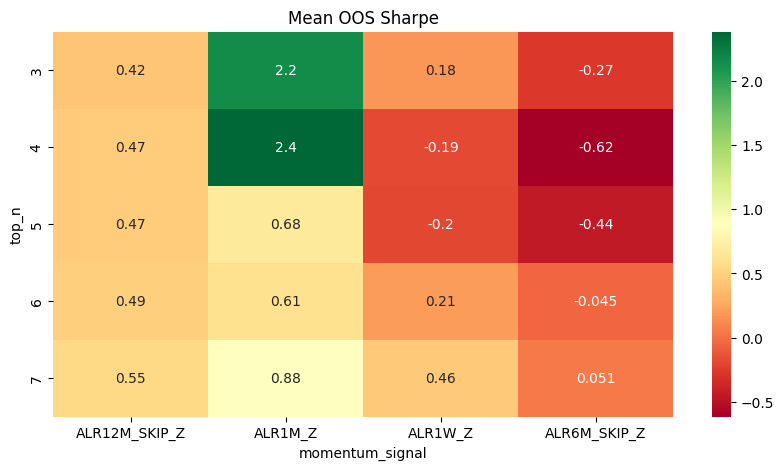

In [11]:
pivot = df_wf.pivot_table(
    values="Sharpe_Test",
    index="top_n",
    columns="momentum_signal",
    aggfunc="mean"
)

plt.figure(figsize=(10,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="RdYlGn"
)

plt.title(
    "Mean OOS Sharpe"
)

plt.show()

## 7. Desempeño por régimen de mercado

In [12]:
df_wf.groupby(
    "active_cluster"
)["Sharpe_Test"].describe()

,count,mean,std,min,25%,50%,75%,max
active_cluster,,,,,,,,
0,608.0,0.182097,0.422986,-1.279,-0.13200,0.266,0.48675,1.415
2,14.0,2.317857,0.113991,2.153,2.20075,2.344,2.41600,2.433
3,14.0,1.856286,0.349637,1.402,1.49725,1.783,2.20800,2.208
4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: title={'center': 'Sharpe_Test'}, xlabel='active_cluster'>

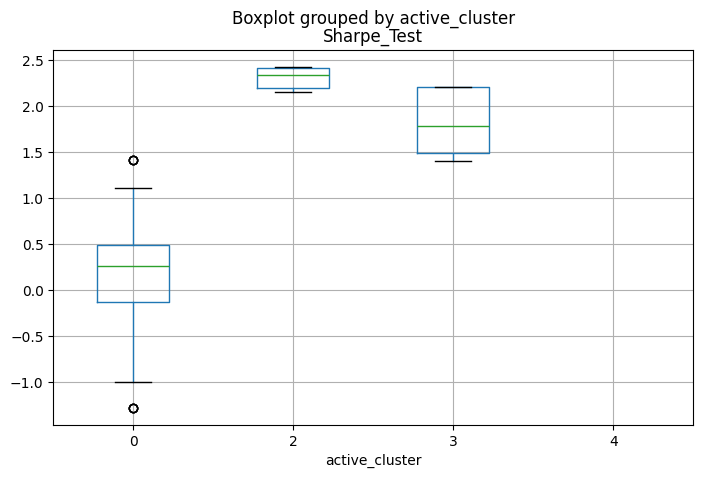

In [13]:
df_wf.boxplot(
    column="Sharpe_Test",
    by="active_cluster",
    figsize=(8,5)
)

In [14]:
summary_rows = []

for p, f in freqs.items():

    dominant_value = f.index[0]
    dominant_freq = f.iloc[0]

    summary_rows.append(
        {
            "Parameter": p,
            "Dominant_Value": dominant_value,
            "Frequency": dominant_freq,
        }
    )

summary_df = pd.DataFrame(summary_rows)

summary_df

,Parameter,Dominant_Value,Frequency
0,top_n,7,0.48
1,rebalance_freq,M,1.00
2,anomaly_lookback_days,1,0.26
3,momentum_signal,ALR1M_Z,0.56
4,active_cluster,0,0.44
5,rank_weighted,False,0.68
6,min_portfolio_size,4,0.52


In [15]:
final_summary = summary_df.merge(
    importance_df,
    left_on="Parameter",
    right_on="Variable",
    how="left"
)

final_summary = final_summary[
    [
        "Parameter",
        "Dominant_Value",
        "Frequency",
        "Importance",
    ]
]

final_summary.sort_values(
    "Importance",
    ascending=False,
)

,Parameter,Dominant_Value,Frequency,Importance
4,active_cluster,0,0.44,0.460022
3,momentum_signal,ALR1M_Z,0.56,0.280287
1,rebalance_freq,M,1.00,0.092453
0,top_n,7,0.48,0.091886
5,rank_weighted,False,0.68,0.058607
6,min_portfolio_size,4,0.52,0.016474
2,anomaly_lookback_days,1,0.26,0.000270


# Conclusiones

El análisis Walk-Forward realizado sobre las configuraciones generadas mediante búsqueda sistemática de hiperparámetros permite identificar qué factores contribuyen de forma más consistente al rendimiento Out-of-Sample de la estrategia propuesta.

## Importancia de los hiperparámetros

El análisis mediante Random Forest muestra que la variable con mayor capacidad explicativa sobre el Sharpe Ratio Out-of-Sample es el régimen de mercado seleccionado (`active_cluster`), con una importancia relativa cercana al 46%.

La segunda variable más relevante es la señal de momentum utilizada (`momentum_signal`), con aproximadamente un 28% de importancia relativa.

Por el contrario, el parámetro asociado al horizonte temporal del detector de anomalías (`anomaly_lookback_days`) presenta una importancia prácticamente nula, lo que sugiere que, dentro de los valores analizados, el rendimiento de la estrategia es poco sensible a esta configuración.

En conjunto, los resultados indican que la segmentación de regímenes mediante K-Means constituye el principal factor explicativo del comportamiento Out-of-Sample.

## Patrones observados en las configuraciones más exitosas

El estudio de frecuencias realizado sobre las 50 configuraciones con mayor Sharpe Ratio Out-of-Sample permite identificar patrones recurrentes:

- El rebalanceo mensual (`M`) aparece en el 100% de las mejores configuraciones.
- La señal de momentum `ALR1M_Z` está presente en el 56% de los casos.
- El tamaño de cartera más frecuente es `top_n = 7`, presente en el 48% de las configuraciones líderes.
- La opción `rank_weighted = False` aparece en el 68% de las mejores estrategias.
- El valor más habitual para `min_portfolio_size` es 4 activos.

Estos resultados sugieren que las configuraciones más robustas tienden a favorecer una actualización frecuente de posiciones, una señal de momentum de corto plazo y una cartera moderadamente concentrada.

## Interacción entre régimen de mercado y señal de momentum

El análisis conjunto de los resultados muestra que el rendimiento de la estrategia depende principalmente de dos factores: el régimen de mercado seleccionado y la señal de momentum utilizada.

Los regímenes asociados a los clusters 2 y 3 presentan valores de Sharpe Ratio significativamente superiores al cluster 0, alcanzando medianas próximas a 2.3 y 1.8 respectivamente. Esto indica que la segmentación mediante K-Means captura estructuras de mercado con comportamientos claramente diferenciados desde el punto de vista de la rentabilidad ajustada al riesgo.

Asimismo, el análisis de sensibilidad entre tamaño de cartera y señal de momentum revela que ALR1M_Z domina sistemáticamente al resto de señales evaluadas. Las mejores combinaciones Out-of-Sample se obtienen utilizando ALR1M_Z junto con carteras relativamente concentradas, especialmente para valores de top_n entre 3 y 4 activos.

Por el contrario, la señal ALR6M_SKIP_Z presenta resultados consistentemente inferiores e incluso negativos para la mayoría de configuraciones analizadas, lo que sugiere una menor capacidad para capturar persistencia de rendimientos dentro del universo estudiado.

## Conclusión general

La evidencia obtenida respalda la hipótesis de que la combinación de filtrado topológico mediante DBSCAN y segmentación de regímenes mediante K-Means aporta información relevante para mejorar el comportamiento de estrategias momentum fuera de muestra.

Más allá de identificar una configuración concreta como óptima, el análisis permite detectar patrones estables que aparecen de forma recurrente entre las estrategias con mejor desempeño Out-of-Sample. Este enfoque resulta más robusto frente al sobreajuste y proporciona una base más sólida para futuras extensiones del modelo.